# Machine Learning — Assignment 2 — Hypothesis Complexity and Linear Models

University of Granada (UGR), 2022–23  
Author: **Juan Pablo Escudero Ramírez**

VC dimension, noise, linear classification (PLA, pocket, logistic regression), and model comparison.

---


## <font color='blue'>Exercise 1: HYPOTHESIS COMPLEXITY AND NOISE (4 points)</font>

<font color='blue'>En este exercise intentaremos profundizar un poco en la dificultad que introduce el ruido de las etiquetas en la elección de la clase de funciones más adecuada para resolver un determinado problema. 



In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Fijamos la semilla aleatoria
np.random.seed(1)


In [ ]:
# Environment: works locally (GitHub/Jupyter) and on Google Colab
import sys
from pathlib import Path

from paths import ROOT, get_data
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")


<font color='blue'>Haremos uso de tres funciones, que se incluyen a continuación: 

<font color='blue'>$simula\_unif(N, dim, rango)$, que calcula una lista de $N$ vectores de dimensión $dim$. Cada vector contiene $dim$ números aleatorios uniformes en el intervalo $rango$.


In [ ]:
def simula_unif(N, dim, rango):
	return np.random.uniform(rango[0],rango[1],(N,dim))


<font color='blue'>$simula\_gauss(N, dim, sigma)$, que calcula una lista de longitud $N$ de vectores de dimensión $dim$, donde cada posición del vector contiene un número aleatorio extraído de una distribucción Gaussiana de media 0 y varianza dada (para cada dimension, por la posición del vector $sigma$).


In [ ]:
def simula_gauss(N, dim, sigma):
    media = 0    
    out = np.zeros((N,dim),np.float64)        
    for i in range(N):
        # Para cada columna dim se emplea un sigma determinado. Es decir, para 
        # la primera columna (eje X) se usará una N(0,sqrt(sigma[0])) 
        # y para la segunda (eje Y) N(0,sqrt(sigma[1]))
        out[i,:] = np.random.normal(loc=media, scale=np.sqrt(sigma), size=dim)
    
    return out


<font color='blue'>$simula\_recta(intervalo)$, que simula de forma aleatoria los parámetros $v = (a, b)$ de una
recta, $y = ax + b$, dado un determinado intervalo (dentro del cual se generan dos points aleatorios, que se emplearán para calcular la pendiente y el término independiente de la recta).


In [ ]:
def simula_recta(intervalo):
    points = np.random.uniform(intervalo[0], intervalo[1], size=(2, 2))
    x1 = points[0,0]
    x2 = points[1,0]
    y1 = points[0,1]
    y2 = points[1,1]
    # y = a*x + b
    a = (y2-y1)/(x2-x1) # Cálculo de la pendiente.
    b = y1 - a*x1       # Cálculo del termino independiente.
    
    return a, b


#### <font color='blue'>a)  (1 punto) Visualización de points iniciales.

<font color='blue'>Vamos a valorar la influencia del ruido en la selección de la clase de funciones y su complejidad. Con ayuda de la función $simula\_unif()$ generamos una
muestra de 100 points 2D, en el intervalo $[-50, 50]$,  a los que vamos añadir una etiqueta usando el signo de la función $f(x, y) = y - ax - b$, es decir el signo de la distancia de cada punto a la recta simulada con
$simula\_recta()$.

Dibujar un gráfico 2D con los points etiquetados. Dibuje también la recta usada para etiquetar. Observe y verifique (por medio del error de clasificación) que todos los points están bien clasificados respecto de la recta.
</font>


##### Funciones


Funciones dadas como base en la práctica. 
* *Signo* convierte el valor entregado como parametro en -1 ó 1.
* *f* pasa como parametro un valor resultado de una serie de operaciones de los suyos propios a la función anterior.


In [ ]:
"""
np.sign(0) da 0 (véase https://numpy.org/doc/stable/reference/generated/numpy.sign.html), lo que, en ciertas ocasiones, puede ser problemático
Por ese motivo, proporcionamos esta sencilla función que devuelve el signo del valor que se le proporciona como entrada
Si esta función se emplea con un array, se obtendrá el error "ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()"
Si quiere poder emplearse con arrays, bastaría vectorizarla:
		numeros = np.random.randint(-10,10,10)
		sgn = np.vectorize(signo)
		print(numeros)
		print(sgn(numeros))
"""
def signo(x):
	if x >= 0:
		return 1
	return -1

def f(x, y, a, b):
	return signo(y - a*x - b)


Esta función grafica la muestra con su etiquetado. Además, muestra la recta que utiliza los parametros *a* y *b*.


In [ ]:
def mostrar_clasif(x, tags, a, b, titulo, leyenda_1, leyenda_2):
  fig = plt.figure()
  ax = fig.add_subplot()
  
  #Dimensiones
  min_x = np.min(x[:, 0])
  max_x = np.max(x[:, 0])
  min_y = np.min(x[:, 1])
  max_y = np.max(x[:, 1])

  #Muestra
  x_positiva = [x[0]]
  x_negativa = [x[0]]

  #Filtro
  if (tags.shape[0] > 1):
    for i in range(1, tags.shape[0]):
      if (tags[i] > 0):
        x_positiva = np.append(x_positiva, [x[i]], axis = 0)
      else:
        x_negativa = np.append(x_negativa, [x[i]], axis = 0)
  
  #Representación de los puntos
  ax.scatter(x_positiva[:, 0], x_positiva[:, 1], c = "Green", label = leyenda_1)
  ax.scatter(x_negativa[:, 0], x_negativa[:, 1], c = "Red", label = leyenda_2)

  #Recta
  X = np.linspace(min_x, max_x, len(x))
  Y = (a * X) + b
  
  ax.plot(X, Y,"b-")

  #Rango de la ax
  ax.set_xlim((min_x, max_x))
  ax.set_ylim((min_y, max_y))

  #Titulo
  ax.set_title(titulo)

  #Leyenda
  ax.legend(loc = "upper right")

  plt.show()


Esta función calcula el error de clasificación contando los points mal clasificados y devuelve tal valor.


In [ ]:
def ErrorClasificacion(x, tags, a, b):
  error = 0

  # Contar los points mal clasificados
  for i in range(0, x.shape[0]):
    if (f(x[i, 0], x[i, 1], a, b) != tags[i]):
      error += 1

  return (np.float64(error) / np.float64(x.shape[0])) * 100.0


Esta función etiqueta una muestra utilizando la función dada 'f'. Necesita varios parametros como la muestra (x), y el resultado de la función *simula_recta*.


In [ ]:
def etiquetado(x,a,b):
  tags = np.empty(x.shape[0])

  # Etiquetar cada punto de la muestra
  for i in range(0, tags.shape[0]):
    tags[i] = f(x[i, 0], x[i, 1], a, b)
  
  return tags


##### Experimento


Éste experimento consta de varias acciones.
* Mediante *simula_recta* se obtienen los valores *a* y *b* que serán necesarios para la recta. 
* La muestra se genera utilizando la función que se nos concedió llamada *simula_unif*.
* Se generan las etiquetas con la función *etiquetado* y se almacenan en *tags*.
* Se calcula el error de clasificación utilizando *ErrorClasificacion*
* Finalmente se muestra la grafica de la muestra etiquetada con la división obtenida.


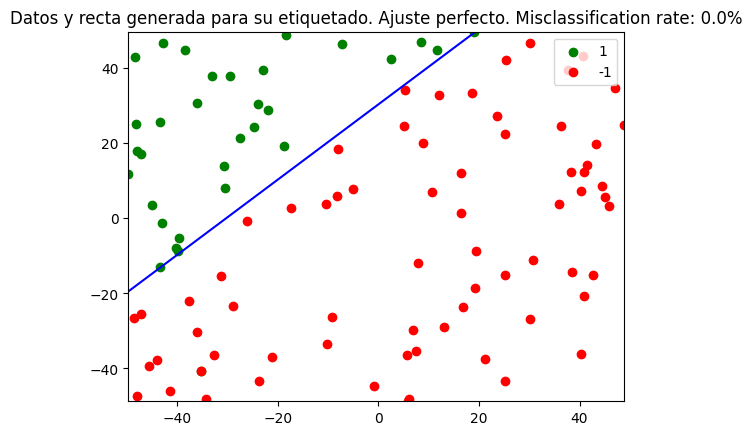

In [ ]:
intervalo = [-50,50]

# Recta y points etiquetados
a, b = simula_recta(intervalo)

# Muestras
x = simula_unif(100, 2, intervalo) 

tags = etiquetado(x,a,b)

err1_a = ErrorClasificacion(x, tags, a, b)
title1_a = "Datos y recta generada para su etiquetado. Ajuste perfecto. Misclassification rate: " + str(err1_a) + "%"

# Gráfica
mostrar_clasif(x, tags, a, b, title1_a, "1", "-1")


##### Conclusiones


Tras realizar el experimento anterior y poder observar su resultado se pouede notar que todos la muestra está correctamente etiquetada. Todos los points negativos y positivos son separados por la recta, puesto que el etiquetado de estos se dio usando la función *f*, que se da con signo(y - ax - b),  los que tuvieran un valor positivo o cero se situan en el lado positivo de la recta mientras que los que tuvieron un valor negativo se situan en el otro lado. Como los points están clasificados correctamente, el error de clasificación es cero.


#### <font color='blue'>b) (0.5 points)  Introducción de ruido. 
Modifique de forma aleatoria un 10\% de las etiquetas positivas y otro
10\% de las negativas y guarde los points con sus nuevas etiquetas. Dibuje de nuevo
la gráfica anterior. Ahora habrá points mal clasificados respecto de la recta.</font>


##### Funciones


Esta función mete ruido a un conjunto de etiquetas, se le mete ruido en un porcentaje a las etiquetas clasificadas como positivas y otro a porcentaje a las etiquetas clasificadas como negativas. Estos porcentajes se pasan como parámetros junto a las propias etiquetas.


In [ ]:
def noise(tags, pos_cant, neg_cant):
  tags_noise = np.copy(tags)


  ind_pos = np.where(np.array(tags_noise) == 1)[0]
  ind_neg = np.where(np.array(tags_noise) == -1)[0]
  
  # Mezclar los indices
  np.random.shuffle(ind_pos)
  np.random.shuffle(ind_neg)

  for i in range(0, np.uint64(np.round(ind_pos.shape[0] * pos_cant))):
    tags_noise[ind_pos[i]] = -1
  
  for i in range(0, np.uint64(np.round(ind_neg.shape[0] * neg_cant))):
    tags_noise[ind_neg[i]] = 1

  return tags_noise


##### Experimento


Este experimento consta de pocas acciones:
* Se le introduce ruido a las etiquetas.
* Se calcula el nuevo error de clasificación.
* Se muestra la gráfica del resultado.


In [ ]:
tags_noise = noise(tags,0.1,0.1)


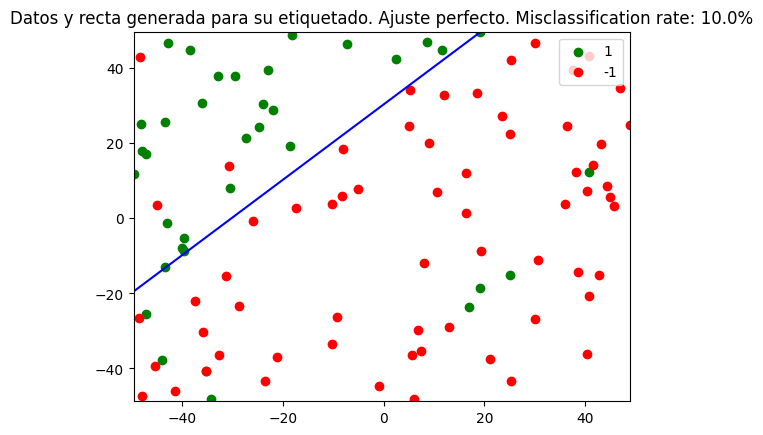

In [ ]:
err1_b = ErrorClasificacion(x, tags_noise, a, b)
title1_b = "Datos y recta generada para su etiquetado. Ajuste perfecto. Misclassification rate: " + str(err1_b) + "%"

mostrar_clasif(x, tags_noise, a, b, title1_b, "1", "-1")


##### Conclusiones


Tras introducir ruido a la muestra (10% tanto a las etiquetas positivas como a las negativas) se contempla que la implementación ha sido correcta pues la función *ErrorClasificacion* nos da un error del 10%. Este valor es entendible puesto que se ha introducido un 10% a cada clase lo que a manera general consigue un 10% de ruido a la muestra completa. Sin embargo, hay que tener en cuenta que el redondeo es peligroso ya que hay numeros que al aplicarle los porcentajes no sea exacto.


#### <font color='blue'>c) (2.5 points)  Análisis y comparación de distintas fronteras de decisión. 
Supongamos ahora que las siguientes funciones definen la frontera de
clasificación de los points de la muestra en lugar de una recta.</font>

<font color='blue'>$f_1(x, y) = (x - 10)^2 + (y - 20)^2 - 400$</font>

<font color='blue'>$f_2(x, y) = 0.5(x + 10)^2 + (y - 20)^2 - 400$</font>

<font color='blue'>$f_3(x, y) = 0.5(x - 10)^2 - (y + 20)^2 - 400$</font>

<font color='blue'>$f_4(x, y) = y - 20x^2 - 5x + 3$</font>


<font color='blue'>

Visualizar el etiquetado generado en el Apartado (b) junto con la gráfica de cada
una de las funciones. Muéstrense los porcentajes de acierto en clasificación para las funciones (es decir, fronteras de decisión) evaluadas. Argumente si estas funciones más
complejas son mejores clasificadores que la función lineal. Observe las gráficas y diga
qué consecuencias extrae sobre la influencia de la modificación de etiquetas
en el proceso de aprendizaje. En concreto, razone sobre cuestiones como las siguientes: ¿Necesariamente funciones más complejas son mejores clasificadores (es decir, representan “mejores” bordes de decisión)? ¿Es posible superar/mejorar ese 10% de error de clasificación? ¿Qué pasa si repetimos el proceso con estas funciones más complejas (las empleamos para etiquetar los datos y luego metemos un 10% de ruido)? ¿Qué error de clasificación tenemos? ¿Es menor que ese 10%?
</font>



##### Funciones


In [ ]:
"""
Esta función permite visualizar las fronteras de decisión.

Entradas: 
- X: datos de entrada con tantas filas como ejemplos, y tantas columnas como dimensiones/features
- y: etiquetas
- fz: función que define la frontera de decisión
- title: título que se le quiere poner a la figura
- xaxis: nombre que se le quiere poner al eje X
- yaxis: nombre que se le quiere poner al eje Y

Salida: visualización de los datos junto con la frontera de decisión proporcionada

Ejemplo de uso: 
def f_prueba(X):
	return X[:,0]**2 + X[:,1]**2 - 200
plot_datos_cuad(X, y, f_prueba, title=r'$f_{prueba}(x, y) = x^2 + y^2 - 200$')
"""
def plot_datos_cuad(X, y, fz, title='Point cloud plot', xaxis='x axis', yaxis='y axis'):
    #Preparar datos
    min_xy = X.min(axis=0)
    max_xy = X.max(axis=0)
    border_xy = (max_xy-min_xy)*0.01
    
    #Generar grid de predicciones
    # np.mgrid es una versión multidimensional de meshgrid (https://numpy.org/doc/stable/reference/generated/numpy.mgrid.html)
    xx, yy = np.mgrid[min_xy[0]-border_xy[0]:max_xy[0]+border_xy[0]+0.001:border_xy[0], 
                      min_xy[1]-border_xy[1]:max_xy[1]+border_xy[1]+0.001:border_xy[1]]
    # np.ravel "aplana" un array (https://numpy.org/doc/stable/reference/generated/numpy.ravel.html)
    # Diferencias entre ravel y flatten: https://stackoverflow.com/questions/28930465/what-is-the-difference-between-flatten-and-ravel-functions-in-numpy
    # np.c_ permite concatenar arrays a lo largo del segundo eje (https://numpy.org/doc/stable/reference/generated/numpy.c_.html)
    grid = np.c_[xx.ravel(), yy.ravel(), np.ones_like(xx).ravel()]
    pred_y = np.sign(fz(grid)).reshape(xx.shape)
    
    #Plot
    f, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(xx, yy, pred_y, 50, cmap='RdBu',vmin=-1, vmax=1)
    ax_c = f.colorbar(contour)
    ax_c.set_label('$f(x, y)$')
    ax_c.set_ticks([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, linewidth=1, 
                cmap="RdYlBu", edgecolor='white')
    
    XX, YY = np.meshgrid(np.linspace(round(min(min_xy)), round(max(max_xy)),X.shape[0]),np.linspace(round(min(min_xy)), round(max(max_xy)),X.shape[0]))
    positions = np.vstack([XX.ravel(), YY.ravel()])
    # ax.contour(XX,YY,fz(positions.T).reshape(X.shape[0],X.shape[0]),[0], colors='white')
    
    ax.set(
       xlim=(min_xy[0]-border_xy[0], max_xy[0]+border_xy[0]), 
       ylim=(min_xy[1]-border_xy[1], max_xy[1]+border_xy[1]),
       xlabel=xaxis, ylabel=yaxis)
    plt.title(title)
    plt.show()


Funciones a utilizar indicadas por el enunciado.


In [ ]:
def f1(X):
    x = X[:,0]
    y = X[:,1]
    return (x - 10) ** 2 + (y - 20) ** 2 - 400

def f2(X):
    x = X[:,0]
    y = X[:,1]  
    return 0.5 * (x + 10) ** 2 + (y - 20) ** 2 - 400

def f3(X):
    x = X[:,0]
    y = X[:,1]    
    return 0.5 * (x - 10) ** 2 - (y + 20) ** 2 - 400
    
def f4(X):
    x = X[:,0]
    y = X[:,1]  
    return y - 20 * x**2 - 5*x + 3


##### Experimento


$f_1(x,y) = (x-10)^2 + (y-20)^2 - 400$


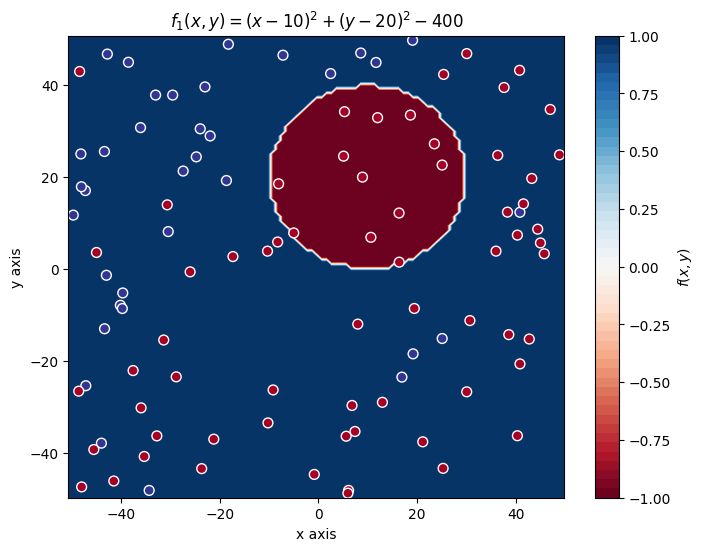

In [ ]:
plot_datos_cuad(x, tags_noise, f1, title = '$f_1(x,y) = (x-10)^2 + (y-20)^2 - 400$')
pred_tags1 = np.sign(f1(x))
MC_rate1 = np.mean(pred_tags1 != tags_noise) * 100
print('Misclassification rate: {}%'.format(MC_rate1))


$f_2(x,y) = 0.5*(x+10)^2 + (y-20)^2 - 400$


Misclassification rate: 53.0%


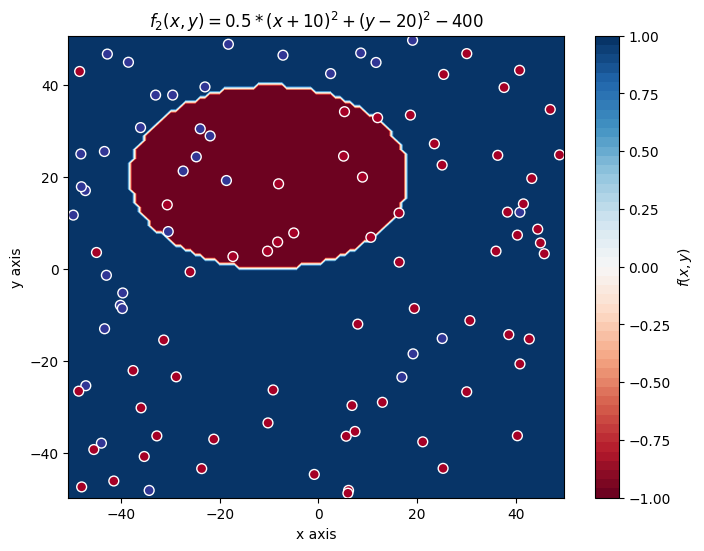

Misclassification rate: 61.0%


In [ ]:
plot_datos_cuad(x, tags_noise, f2, title = '$f_2(x,y) = 0.5*(x+10)^2 + (y-20)^2 - 400$')
pred_tags2 = np.sign(f2(x))
MC_rate2 = np.mean(pred_tags2 != tags_noise) * 100
print('Misclassification rate: {}%'.format(MC_rate2))


$f_3(x,y) = 0.5(x-10)^2 - (y+20)^2 - 400$


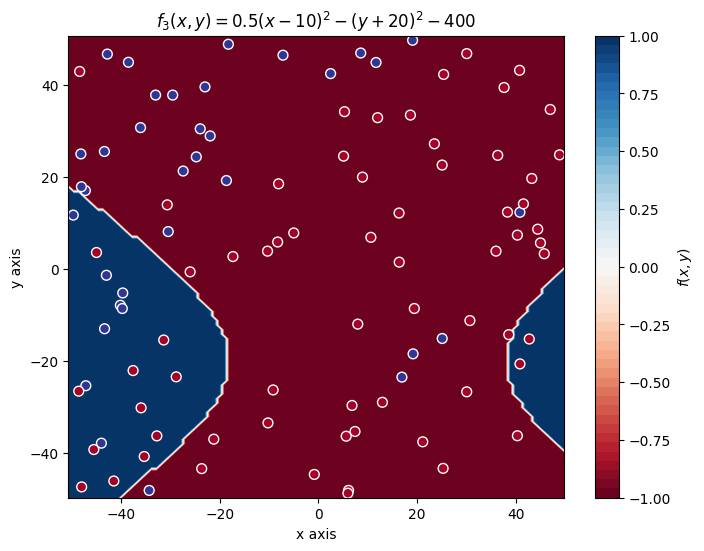

Misclassification rate: 40.00%


In [ ]:
plot_datos_cuad(x, tags_noise, f3, title = '$f_3(x,y) = 0.5(x-10)^2 - (y+20)^2 - 400$')
pred_tags3 = np.sign(f3(x))
MC_rate3 = np.mean(pred_tags3 != tags_noise) * 100
print('Misclassification rate: {:.2f}%'.format(MC_rate3)) 


$f_4(x,y) = y - 20x^2 - 5x + 3$


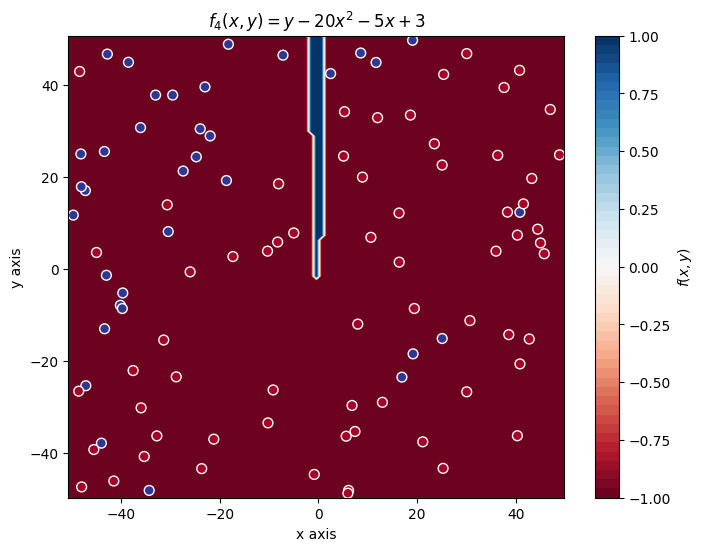

Misclassification rate: 35.00%


In [ ]:
plot_datos_cuad(x, tags_noise, f4, title = '$f_4(x,y) = y - 20x^2 - 5x + 3$')
pred_tags4 = np.sign(f4(x))
MC_rate4 = np.mean(pred_tags4 != tags_noise) * 100
print('Misclassification rate: {:.2f}%'.format(MC_rate4)) 


##### Conclusiones


Observando estos resultados se puede ver que aunque las funciones cónicas son más complejas no significa que sean mejores clasificadoras. Las funciones complejas son útiles cuando no se pueden separar los datos linealmente, en caso contrario no lo son
tanto. Estas funciones permiten que los datos queden ordenados cuando no tienen por qué ser linealmente separables.

Entrando más en profundidad, al observar el porcentaje de error al utilizar las diferentes funciones se puede notar que la que mejor clasifica este caso en concreto es la función del exercise anterior, consiguiente un porcentaje de error muy bajo (10%). Las otras funciones utilizadas en este apartado se alejan mucho de ese porcentaje siendo el más bajo un 35%. Esta situación nos da a entender que la utilización de funciones complejas no tiene porqué das mejores resultados, sino que para cada problema se debe buscar la solución que mejor se adapte. 

Es posible obtener un mejor porcentaje de error al tener en cuenta la muestra a utilizar y la elección de una solución que se ajuste a él. Mediante otras diferentes técnicas de clasificación debe ser posible bajar ese porcentaje.

Si etiquetamos una muestra utilizando una función en especifico, le introducimos un porcentaje de ruido y después obtenemos el porcentaje de error no necesariamente será el mismo. Dependerá mucho de la naturaleza de la función, cómo es la muestra, la distribución y cantidad de ruido introducida pues cambia la etiqueta original, afectando la precisión de la clasificación.


## <font color='blue'>Exercise 2: MODELOS LINEALES (8 points) </font>


### <font color='blue'>Apartado 2.1 (3 points) Algoritmo Perceptrón (PLA). 

<font color='blue'>Implementar la función $ajusta\_PLA(datos, label, max\_iter, vini)$ que calcula el hiperplano solución a un problema de clasificación binaria usando el algoritmo PLA. La entrada $datos$ es una matriz donde cada ejemplo está representado por una fila de la matriz, $label$ el vector de etiquetas (cada etiqueta es
un valor +1 o -1), $max\_iter$ es el número máximo de iteraciones permitidas y $vini$
el valor inicial del vector. La función devuelve, como mínimo, los coeficientes del hiperplano y la iteración de convergencia.  </font>



Este algoritmo busca minimizar el error actualizando el vector de pesos *w*, calculando el hiperplano solución a un problema de clasificación binaria. Itera mientras no se superen las
iteraciones máximas y no haya actualizaciones al recorrer los datos.

Si los datos no son linealmente separables no convergerá y por tanto llegará a su limite de iteraciones.

La implementación de este algoritmo se logró teniendo en cuenta el siguiente pseudocódigo:

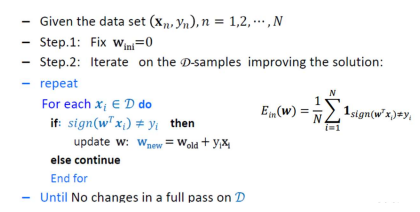


In [ ]:
def ajusta_PLA(datos, label, max_iter, vini):
  w = np.copy(vini)
  ws = [w]
  actual = True
  it = 0

  while (it < max_iter and actual):
    actual = False
    it += 1

    for x, y in zip(datos, label):
      if (signo(x.dot(w)) != y):
        w = w + y*x
        actual = True

    ws = np.append(ws, [w], axis = 0)

  return w, it, ws


<font color='blue'>Ejecutar el algoritmo PLA con los datos empleados en el Apartado (a) del Exercise 1. Inicializar el algoritmo con: 

<font color='blue'>i) el vector cero y, 

<font color='blue'>ii) con vectores de
números aleatorios en [0, 1] (10 veces). 

<font color='blue'>Anotar el número medio de iteraciones
necesarias en ambos para converger. Se deben mostrar en una tabla cada uno de los pesos iniciales empleados, los finales (obtenidos tras el proceso de entrenamiento), y el porcentaje de error de clasificación. También se debe visualizar una nube de points etiquetada junto con la frontera resultante del ajuste. Valorar el resultado relacionando el punto
de inicio con el número de iteraciones. </font>


##### Funciones


Esta función representa gráficamente el resultado de la ejecución de el algoritmo PLA sobre una muestra de la que se tienen etiquetas.


In [ ]:
def mostrar_PLA(w,x, tags, intervalo, title):

  # Mostramos los elementos de la muestra ya etiquetados
  plt.plot(x[tags==1, 0], x[tags==1, 1], 'go', label='1.0')
  plt.plot(x[tags==-1, 0], x[tags==-1, 1], 'ro', label='-1.0')


  # Dibujamos la recta obtenida en la última repetición
  X = np.array([intervalo[0], intervalo[1]])

  Y = -(w[0]+w[1] * X) / w[2]
  lab = 'PLA'
  plt.plot(X, Y, 'b-', label = lab)


  #Titulo de la grafica
  plt.title(title)

  #Leyenda
  plt.legend(loc='lower right')

  #Límites del gráfico
  plt.ylim(intervalo[0], intervalo[1])
  plt.xlim(intervalo[0], intervalo[1])

  #Mostrar gráfica
  plt.show()


Esta función representa gráficamente el resultado de varios resultados de la ejecución del algoritmo PLA sobre una muestra de la que se tienen etiquetas.


In [ ]:
def mostrar_PLA2(was,x, tags, intervalo, title):

  # Mostramos los elementos de la muestra ya etiquetados
  plt.plot(x[tags==1, 0], x[tags==1, 1], 'go', label='1.0')
  plt.plot(x[tags==-1, 0], x[tags==-1, 1], 'ro', label='-1.0')

  # Dibujamos la recta obtenida en la última repetición
  X = np.array([intervalo[0], intervalo[1]])

  pos = True
  for i in was:
    Y = -(i[0]+i[1] * X) / i[2]
    lab = 'PLA'
    if pos == True :
      plt.plot(X, Y, 'b-', label = lab)
      pos = False
    else : 
      plt.plot(X, Y, 'b-')

  #Titulo de la grafica
  plt.title(title)

  #Leyenda
  plt.legend(loc='lower right')

  #Límites del gráfico
  plt.ylim(intervalo[0], intervalo[1])
  plt.xlim(intervalo[0], intervalo[1])

  #Mostrar gráfica
  plt.show()


##### Experimento


###### i)


Esta primera parte consta de diferentes pasos:
* Primero se adaptan los datos para tratarlos.
* Se declara el vector *iterations* que guardará el valor de las iteraciones durante sus dos partes para obtener una media.
* Se declara el valor de los pesos iniciales, que como se indicó será de 0s.
* Se ejecutará el algoritmo PLA.


In [ ]:
def transform_muestra(muestra):
    muestra_c = np.array([np.ones(int(muestra.size / 2)), muestra[:, 0], muestra[:, 1]])
    
    return muestra_c.transpose()


In [ ]:
# Guardamos en X la matriz x con la primera columna con 1s
X = transform_muestra(x)

# Caso vector pesos inicial de 0s
w0 = np.zeros(X.shape[1]) # vector inicial pesos 0s

# Ejecución del algoritmo
w, iters, ws = ajusta_PLA(X, tags, 1000, w0)


Tras la ejecución se obtiene el error de clasificación: 


In [ ]:
# Error de clasificacion
tags_pred = np.sign(X.dot(w))
err = round((np.sum(tags_pred != tags) / tags.shape[0]) * 100, 2)


Tabla de resultados:


In [ ]:
print("W_ini:",w0,"\tW_fin:",w,"\tIteraciones:",iters,"\tError:",err)


W_ini: [0. 0. 0.] 	W_fin: [-587.          -19.50154253   19.79007314] 	Iteraciones: 34 	Error: 0.0


Gráfica con el resultado:


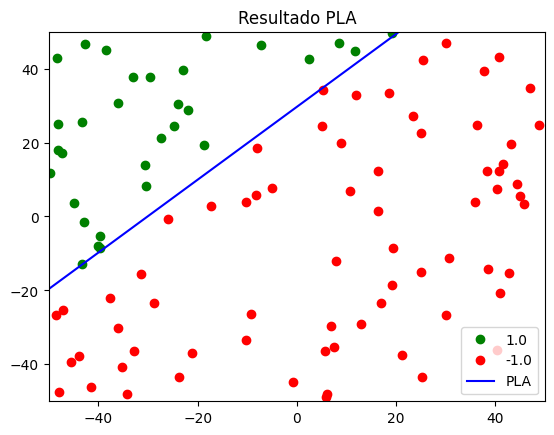

In [ ]:
mostrar_PLA(w,x,tags,intervalo,'Resultado PLA')


---------------------------------


###### ii)


En este apartado se ejecutará el algoritmo 10 veces consiguiendo una tabla de valores que muestra:
* Pesos iniciales.
* Pesos obtenidos al ejecutar el algoritmo.
* Iteraciones necesitadas para converger.
* Porcentaje de error obtenido en cada caso.


In [ ]:
#Vectores de números aleatorios en [0, 1] (10 veces). 

print('\t\tw0','\t\t\t\t\tw','\t\t\t\tIteraciones','\t\t\tError')

iterations = []
w_varios = []

for i in range(0, 10):
    # Vector con valores aleatorios entre [0,1]
    w0 = np.random.uniform(0, 1, X.shape[1]) 

    w, iters, ws = ajusta_PLA(X, tags, 1000, w0)

    #Calculamos error de clasificacion
    tags_pred = np.sign(X.dot(w))
    err = round((np.sum(tags_pred != tags) / tags.shape[0]) * 100, 2)

    val0 = str(w0)
    val1 = str(w)
    val2 = str(iters)
    val3 = str(err)

    iterations.append(iters)
    w_varios.append(w)

    print(val0,val1,"\t\t",val2,"\t\t\t",val3)


		w0 					w 				Iteraciones 			Error
[0.62191937 0.43024727 0.97380208] [-1184.37808063   -42.01989557    40.61334943] 		 138 			 0.0
[0.67780089 0.19856989 0.42670101] [-1094.32219911   -40.7662392     38.06531562] 		 110 			 0.0
[0.34334624 0.7976388  0.87999829] [-574.65665376  -21.16238579   19.84807917] 		 34 			 0.0
[0.90384196 0.66271981 0.27020826] [-698.09615804  -23.23604385   23.6589101 ] 		 44 			 0.0
[0.2523667  0.85489794 0.52771465] [-1374.7476333    -53.97549007    48.38996627] 		 209 			 0.0
[0.80216108 0.57248852 0.73314253] [-782.19783892  -29.67251975   27.19225348] 		 56 			 0.0
[0.51901163 0.77088391 0.56885799] [-579.48098837  -19.72023238   19.95601999] 		 33 			 0.0
[0.46570988 0.34268891 0.06820935] [-1177.53429012   -44.53391497    41.15109439] 		 135 			 0.0
[0.37792418 0.07962608 0.98281711] [-1188.62207582   -44.08710381    40.91177528] 		 143 			 0.0
[0.18161285 0.8118587  0.87496164] [-574.81838715  -21.1481659    19.84304252] 		 34 			 0.0


Resultado de todas las ejecuciones del algoritmo.


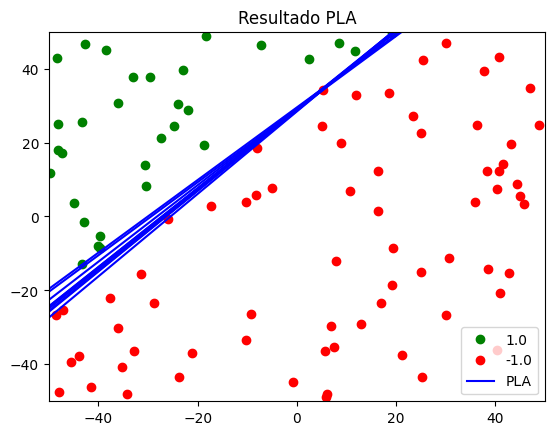

In [ ]:
mostrar_PLA2(w_varios,x,tags,intervalo,'Resultado PLA')


Iteraciones medias:


In [ ]:
print(np.mean(np.asarray(iterations)))


93.6


##### Conclusiones


Como se comentó antes, este algoritmo solo convergerá si la muestra es linealmente seprabale. En este caso en el que no existe el ruido, se aprecia como el algoritmo hace su trabajo sin llegar a las iteraciones máximas fijadas, por lo que se puede decir que en estos casos la muestra es separable.

En la primera parte se ejecuta el algoritmo  utilizando un vector de pesos inicial de ceros, obteniendo 34 iteraciones. Al converger utilizando este algoritmo podemos decir que en este caso los datos son linealmente separables.

En la segunda etapa de este exercise se repitió lo anterior con 10 pesos iniciales diferentes, adquiriendo así diferentes resultados aunque todos enlazados a un buen desempeño pues el porcentaje de error en todos ellos es 0. Lo que varía son las épocas que necesitaron para llegar a esa separación buscada. La media de iteraciones en este caso es más elevada que la anterior (34). Esta media cambia cada vez que se ejecuta pues al usar pesos iniciales aleatorios, las iteraciones necesarias para converger no se pueden asegurar.

Teniendo todo esto en cuenta puedo decir que este algoritmo es muy sensible al punto inicial, cambiando en gran medida el tiempo (iteraciones) necesario para converger, si es que es posible pues como ya se ha dicho, si directamente no es linealmente separable, no convergerá sino que consumirá todas su iteraciones. Sin embargo, puede llegar a no converger aunque la muestra si que sea separable. La distancia a la convergencia la determina la proximidad de los pesos iniciales a unos pesos que separen la muestra, por lo que cuanto más cerca se encuentre, más rápido convergerá. Conociendo ya el cuidado que se debe tener con los points iniciales al utilizar este algoritmo, si se establecen de una muy mala manera puede llegar al punto de no converger y consumir todas sus iteraciones, por lo que aunque la muestra fuera linealmente separable, el algoritmo no sería capaz de cumplir su función.

Una anotación final al observar la gráfica es que todos los resultados clasifican de una forma correcta en el mismo area, que es en el que es posible la separación, por lo que si la muestra aumentara considerablemente su tamaño, esa area se vería reducida limitando más las posibles separaciones que se pueden asignar.


##### <font color='blue'>Ahora, hay que hacer lo mismo usando  los datos del Apartado (b) del Exercise 1, y $150.000$ como número máximo de iteraciones. ¿Se observa algún comportamiento diferente? En caso afirmativo, diga cuál y las
razones para que ello ocurra. </font>


##### Experimento


###### i)


In [ ]:

# Caso vector pesos inicial de 0s

w0 = np.zeros(X.shape[1]) # vector inicial pesos 0s

w, iters, ws = ajusta_PLA(X, tags_noise, 150000, w0)


In [ ]:
# Error de clasificacion
tags_noise_pred = np.sign(X.dot(w))
err = round((np.sum(tags_noise_pred != tags_noise) / tags_noise.shape[0]) * 100, 2)


In [ ]:
print("W_ini:",w0,"\tW_fin:",w,"\tIteraciones:",iters,"\tError:",err)


W_ini: [0. 0. 0.] 	W_fin: [-803.          -31.04047112   28.34372739] 	Iteraciones: 150000 	Error: 11.0


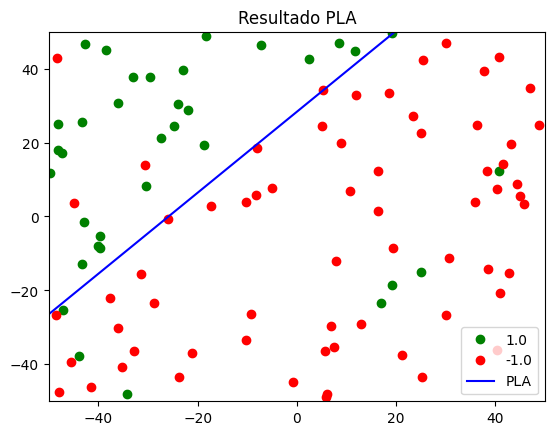

In [ ]:
mostrar_PLA(w,x,tags_noise,intervalo,'Resultado PLA')


---------------------------------


###### ii)


In [ ]:
#Vectores de números aleatorios en [0, 1] (10 veces). 

print('\t\tw0','\t\t\t\t\tw','\t\t\t\tIteraciones','\t\t\tError')

w_varios2 = []
iterations2 = []

for i in range(0, 10):
    # Vector con valores aleatorios entre [0,1]
    w0 = np.random.uniform(0, 1, X.shape[1]) 

    w, iters, ws = ajusta_PLA(X, tags_noise, 150000, w0)

    #Calculamos error de clasificacion
    tags_noise_pred = np.sign(X.dot(w))
    err = round((np.sum(tags_noise_pred != tags) / tags_noise.shape[0]) * 100, 2)

    val0 = str(w0)
    val1 = str(w)
    val2 = str(iters)
    val3 = str(err)

    iterations2.append(iters)
    w_varios2.append(w)

    print(val0,val1,"\t\t",val2,"\t\t\t",val3)


		w0 					w 				Iteraciones 			Error
[0.68841325 0.56949441 0.16097144] [-807.31158675  -22.91302671   36.48675931] 		 150000 			 9.0
[0.46688002 0.34517205 0.22503996] [-806.53311998  -27.92449045   41.184607  ] 		 150000 			 10.0
[0.59251187 0.31226984 0.91630555] [-802.40748813  -39.91966886   42.74719553] 		 150000 			 7.0
[0.90963552 0.25711829 0.1108913 ] [-797.09036448  -10.18192355   26.84329841] 		 150000 			 12.0
[0.19296273 0.49958417 0.72858567] [-794.80703727  -31.89050643   28.08152649] 		 150000 			 3.0
[0.20819444 0.24803356 0.85167187] [-773.79180556  -24.97502241   34.90322622] 		 150000 			 8.0
[0.41584872 0.61668507 0.23366614] [-782.58415128  -32.67082274   46.45890235] 		 150000 			 8.0
[0.10196726 0.51585702 0.47714099] [-805.89803274  -38.64305708   44.47398321] 		 150000 			 7.0
[0.15267164 0.62180623 0.54401012] [-800.84732836  -31.01993353   29.54441578] 		 150000 			 1.0
[0.65413735 0.14454554 0.75152782] [-806.34586265  -30.09915267   26.12934119] 		 150000

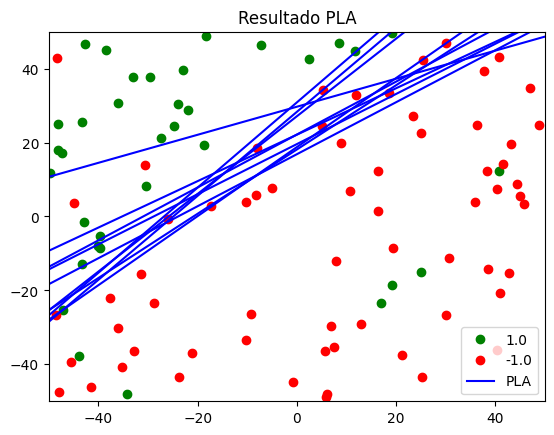

In [ ]:
mostrar_PLA2(w_varios2,x,tags_noise,intervalo,'Resultado PLA')


In [ ]:
print(np.mean(np.asarray(iterations2)))


150000.0


##### Conclusiones


Al introducir ruido al experimento la muestra deja de ser sepatable linealmente, por lo que nunca llegará a converger. Con el peso inicial de ceros ha consumido todas sus iteraciones en comparación a las 34 que necesitó anteriormente. Por ello, como tal no se llega a una solución perfecta. Aún así, viendo el porcentaje de error de algunas ejecuciones del algoritmo, se destaca que son inferiores al 10% que se consiguió clasificar en anteriores exercises, siendo muy buenos resultados si se compara con los que se obtuvieron al utilizar funciones complejas e incluso superando a la mejor clasificación hasta este punto (10%).

En cuanto a las iteraciones medias de la segunda parte son 150000 pues no llegó a converger, consumiendo todas las iteraciones posibles.


### <font color='blue'>Apartado 2.2 (5 points) Regresión Logística (RL). 


<font color='blue'>En este exercise emplearemos nuestra propia función
objetivo $f$ y un conjunto de datos $\mathcal{D}$ para ver cómo
funciona regresión logística. Consideraremos $d = 2$ para que los datos sean fácilmente visualizables, y emplearemos $\mathcal{X} = [0, 2] \times [0, 2]$ con
probabilidad uniforme de elegir cada $x \in \mathcal{X}$. Elegir una línea en el plano que pase por
$\mathcal{X}$ como la frontera que separa la región en donde $y$ toma valores +1 y -1. Para ello, seleccionar dos points aleatorios de $\mathcal{X}$ y calcular la línea
que pasa por ambos. 

<font color='blue'>Impleméntese RL con Gradiente Descendente Estocástico (SGD) del siguiente modo:

> <font color='blue'>1) Inicializar el vector de pesos con valores 0.

> <font color='blue'>2) Parar el algoritmo cuando $\|w^{(t+1)} - w^{(t)}\| < 0.01$, donde $w(t)$ denota el vector
de pesos al final de la época $t$. Recuérdese que una época es un pase completo a través de los $N$
ejemplos de nuestro conjunto de datos.

> <font color='blue'>3) Aplicar una permutación aleatoria de $\{1, 2,..., N\}$ a los índices de los datos, antes
de usarlos en cada época del algoritmo.

</font>


Se pide la implementación de Regresión Logística con Gradiente Descendente
Estocástico. Este consiste en ir actualizando el vector de pesos utilizando el Learning
rate, el gradiente descendiente y el tamaño del batch elegido hasta ajustar bien la
muestra. El criterio para que el algoritmo se detenga es que  $\|w^{(t+1)} - w^{(t)}\| < 0.01$.

El pseudo código utilizado es el siguiente:

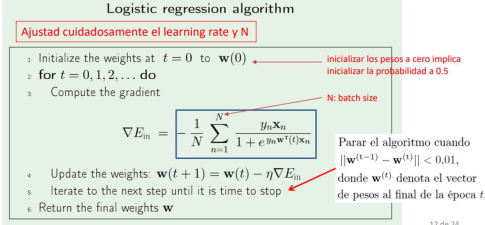


In [ ]:
def gradLR(x,y,w):
    return (-(y*x)/(1 + np.exp(y*np.dot(np.transpose(w),x))))


In [ ]:
def sgdRL(x, y, lr, tam_minibatch, max_epocas):
  
  # (1)
  w = np.zeros(x.shape[1])
  

  #Epoca
  t = 0

  #Conjunto de datos
  N = x.shape[0]

  #Variable condicional
  diff = np.inf

  #Una época es un pase completo a través de los  N  ejemplos de nuestro conjunto de datos
  while(t < max_epocas):
    # (3)
    ind = np.arange(0,len(x))
    np.random.shuffle(ind)

    contador = 0
    batch_ini = 0
    batch_fin = tam_minibatch

    while (contador < N):

      w_old = np.copy(w)

      mini_batch = ind[batch_ini:batch_fin]

      for i in range(0, len(mini_batch)):
        w = w - lr*gradLR(x[mini_batch[i]] , y[mini_batch[i]] , w)


      batch_ini += tam_minibatch
      
      if( (contador + tam_minibatch) >= len(x)):
        batch_fin = len(x)
        contador += tam_minibatch
      else:
        batch_fin += tam_minibatch
        contador += tam_minibatch


    #Condición de parada (2)
    diff = np.linalg.norm(w - w_old)

    if diff < 0.01:
      break

    t += 1


  return w, t


##### <font color='blue'>A continuación, empleando la implementación anterior, realícese el siguiente experimento:
 
> <font color='blue'>1) Seleccione $N = 100$ points aleatorios $\{{\bf x}_n \}$ de $\mathcal{X}$ y evalúe las
respuestas $\{y_n\}$ de todos ellos respecto de la frontera elegida. 

> <font color='blue'>2) Ejecute RL para encontrar la función solución $g$. Visualice la frontera de decisión encontrada, y muestre el $E_{in}$ y el porcentaje de acierto en clasificación correspondientes. Se debe escoger experimentalmente tanto el $\textit{learning rate}$ (tasa de aprendizaje $\eta$) como el tamaño de batch. 

> <font color='blue'>3) Evalúe el error $E_{out}$ usando para ello una nueva muestra de datos ($>999$).  Muéstrense, de nuevo, tanto el ajuste visual, como el $E_{out}$ y el porcentaje de acierto en test. 

> <font color='blue'>4) Repita el experimento anterior (pasos 1-3) $50$ veces, y calcule los valores promedio de $E_{in}$ y $E_{out}$, de porcentaje de error de clasificación (en entrenamiento y test), y de épocas necesarias para converger (en entrenamiento).   

<font color='blue'>Junto con la realización del experimento anteriormente descrito, discuta qué ocurriría si, como criterio de parada, se emplease la diferencia entre pesos obtenidos en sucesivas iteraciones (en lugar de en sucesivas épocas). Del mismo modo, explique cómo ha escogido el $\textit{learning rate}$ y el $\textit{batch size}$, y las conclusiones que extrae al respecto (por ejemplo, ¿valores de $\textit{learning rate}$ como 0.001, cuando se emplea la diferencia de pesos entre épocas como criterio de terminación, funcionan adecuadamente y permiten resolver el problema?). 




##### Funciones


Función para calcular el accuracy.


In [ ]:
def Acc(tags, tags_comp):
    return (tags == tags_comp).mean()


La siguiente función busca representar el error, fue implementada basada en este pseudo-código:

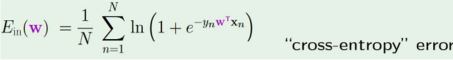


In [ ]:
def Err_(x,y,w):
    
    result = np.float64( np.log( 1 + np.exp( -(y) * (x.dot( w ))  ) ) )
    result.dtype = np.float64
    
    return np.mean(result, axis=0)


Esta función visualiza la muestra etiquetada junto al resultado del algoritmo SGDLR


In [ ]:
def mostrar_SGD(w,x, tags, intervalo, title):

  # Mostramos los elementos de la muestra ya etiquetados
  plt.plot(x[tags==1, 0], x[tags==1, 1], 'go', label='1.0')
  plt.plot(x[tags==-1, 0], x[tags==-1, 1], 'ro', label='-1.0')

  # Dibujamos la recta obtenida del algoritmo
  X = np.array([intervalo[0], intervalo[1]])

  Y = -(w[0]+w[1] * X) / w[2]
  lab = 'SGD'
  plt.plot(X, Y, 'k-', label = lab)

  #Titulo de la grafica
  plt.title(title)

  #Leyenda
  plt.legend(loc='lower right')

  #Límites del gráfico
  plt.ylim(intervalo[0], intervalo[1])
  plt.xlim(intervalo[0], intervalo[1])

  #Mostrar gráfica
  plt.show()


##### 1)


En esta primera parte del experimento se crea una muestra aleatoria y se muestra la grafica con la división mediante la recta.


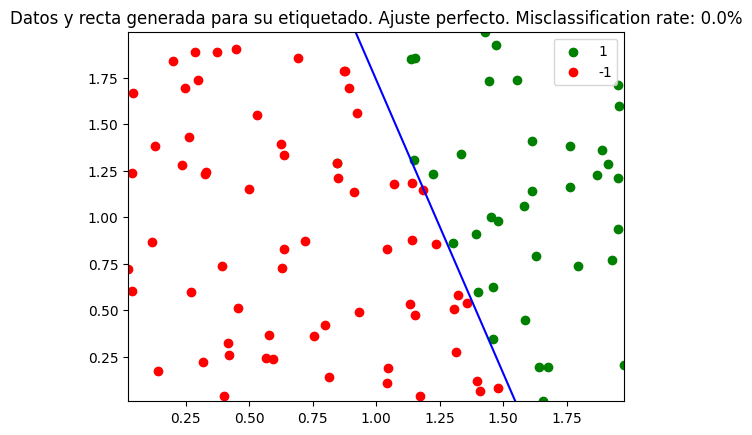

In [ ]:
np.random.seed(0)

intervalo=[0,2]

# Recta y points etiquetados
a, b = simula_recta(intervalo)

# Muestras
x = simula_unif(100, 2, intervalo) 

tags = etiquetado(x,a,b)

err2 = ErrorClasificacion(x, tags, a, b)
title1_a = "Datos y recta generada para su etiquetado. Ajuste perfecto. Misclassification rate: " + str(err2) + "%"

# Gráfica
mostrar_clasif(x, tags, a, b, title1_a, "1", "-1")


Puede observarse que como anteriormente, el rror es 0 y la recta divide perfectamente la muestra al no tener ruido


##### 2)


Se transforman los datos añadiendo una coordenada artificial (una columna).


In [ ]:
X = transform_muestra(x)

w, epocas = sgdRL(X, tags, 0.2, 2*10 , 10000)


Por problemas de ejecución al utilizar la función *Acc* se vectorizó la función.


In [ ]:
f_new = np.vectorize(f)


In [ ]:
print("El algoritmo ha iterado durante",str(epocas),"épocas")
print("W: ",w)
print("Acc: ",Acc(tags,f_new(x[:,0], x[:,1], -w[1]/w[2], -w[0]/w[2])) * 100,"%")
print("Ein de la muestra: ", Err_(X,tags,w))


El algoritmo ha iterado durante 695 épocas
W:  [-36.74007421  23.51934184   7.17253033]
Acc:  99.0 %
Ein de la muestra:  0.05423560279046076


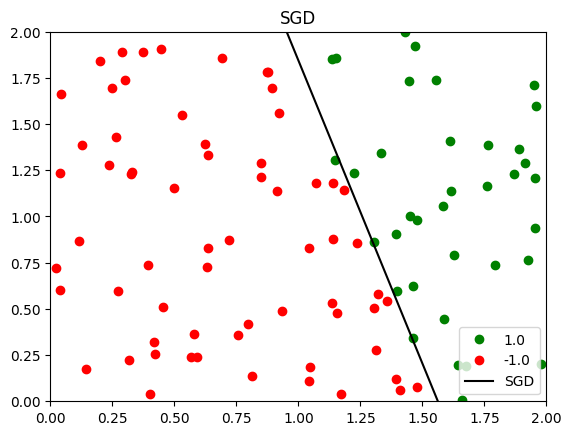

In [ ]:
mostrar_SGD(w,x,tags,intervalo,'SGD')


Utilizando este algoritmo entró en juego el lr y los minibatchs, aunque con un minibatch bajo y un lr de aproximado 0.1-0.01 daba resultados muy buenos a gran velocidad, conseguí el 100% de accuracy con lr de 0.2 y minibatch de 20, multiplo de 2.

Estos valores se obtuvieron mediante la experimentación.


Algunos ejemplos de como se llegó a la elección final.


En este caso se aumentó el tamaño del learning rate.


In [ ]:
w1, epocas1 = sgdRL(X, tags, 8.2, 2*16 , 10000)
print("El algoritmo ha iterado durante",str(epocas1),"épocas")
print("W: ",w1)
print("Acc: ",Acc(tags,f_new(x[:,0], x[:,1], -w1[1]/w1[2], -w1[0]/w1[2])) * 100,"%")
print("Ein de la muestra: ", Err_(X,tags,w1))


El algoritmo ha iterado durante 3 épocas
W:  [-77.81007723  42.50193771  13.69368884]
Acc:  84.0 %
Ein de la muestra:  1.007036018512595


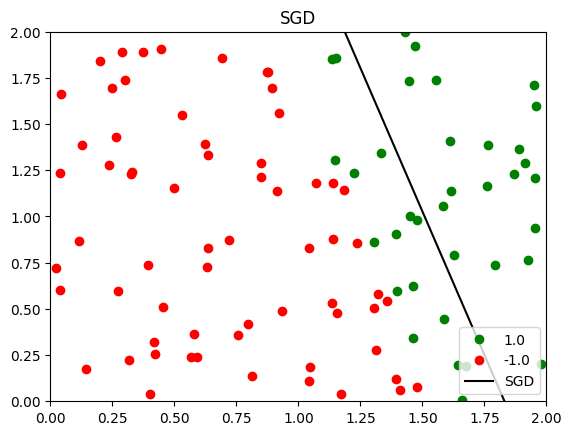

In [ ]:
mostrar_SGD(w1,x,tags,intervalo,'SGD')


Como se puede observar las epocas disminuteron de una forma muy considerable, pero el resultado final no está tan refinado dejando mucho que desear. Aún así en comparación con muchos ejemplos vistos anteriormente, no se puede negar que es un porcentaje de acierto alto.


En el siguiente caso se disminuyó el tamaño del batch.


In [ ]:
w2, epocas2 = sgdRL(X, tags, 0.02, 2 , 10000)
print("El algoritmo ha iterado durante",str(epocas2),"épocas")
print("W: ",w2)
print("Acc: ",Acc(tags,f_new(x[:,0], x[:,1], -w2[1]/w2[2], -w2[0]/w2[2])) * 100,"%")
print("Ein de la muestra: ", Err_(X,tags,w2))


El algoritmo ha iterado durante 10 épocas
W:  [-1.70895818  1.47767139 -0.23620575]
Acc:  14.000000000000002 %
Ein de la muestra:  0.4404271146722153


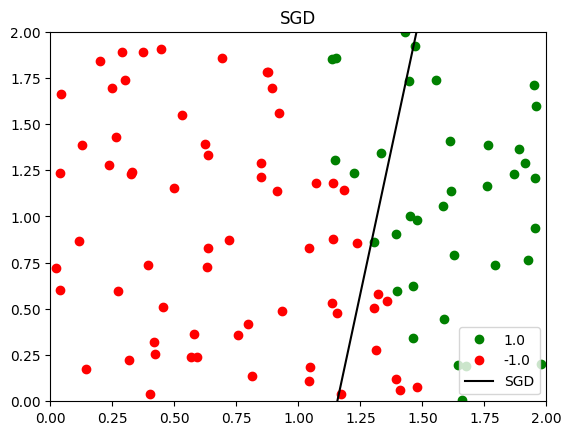

In [ ]:
mostrar_SGD(w2,x,tags,intervalo,'SGD')


Se obserca como su porcentaje de acierto es muy bajo, clasificando de mala manera la muestra. Como tiene tan pocas epocas se intuye que se detuvo de forma precoz por la condición de parada.


Volviendo a la solución principal en la que se logró el 100% de accuracy, se puede notar que no se consumieron todas las iteraciones, por lo que la solución que dio fue tras converger.


##### 3)


Se genera una muestra con un tamaño superior a 999, se etiqueta y se transforman los datos.


In [ ]:
np.random.seed(1)

intervalo=[0,2]
x_test = simula_unif(1000, 2, intervalo)
a , b = simula_recta(intervalo)
tags_test = etiquetado(x_test,a,b)

X_test = transform_muestra(x_test)


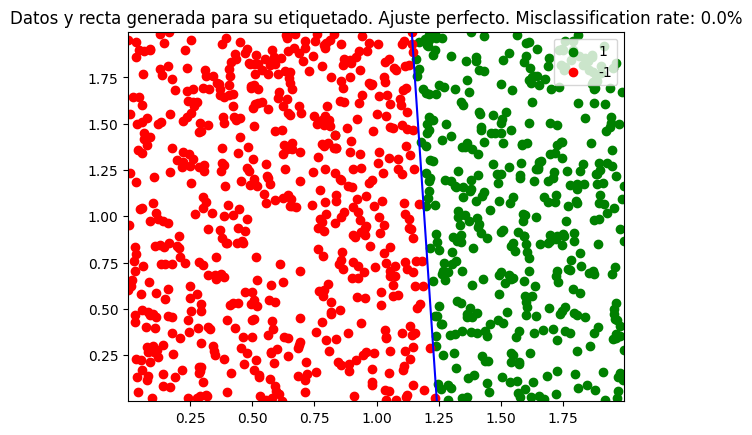

In [ ]:
err21 = ErrorClasificacion(x_test, tags_test, a, b)
title1_a = "Datos y recta generada para su etiquetado. Ajuste perfecto. Misclassification rate: " + str(err21) + "%"

# Gráfica
mostrar_clasif(x_test, tags_test, a, b, title1_a, "1", "-1")


In [ ]:
print("Estimación del error Eout: ", Err_(X_test,tags_test,w))
print("Acc: ",Acc(tags_test,f_new(x_test[:,0], x_test[:,1], -w[1]/w[2], -w[0]/w[2])) * 100,"%")


Estimación del error Eout:  0.21524842409789585
Acc:  92.30000000000001 %


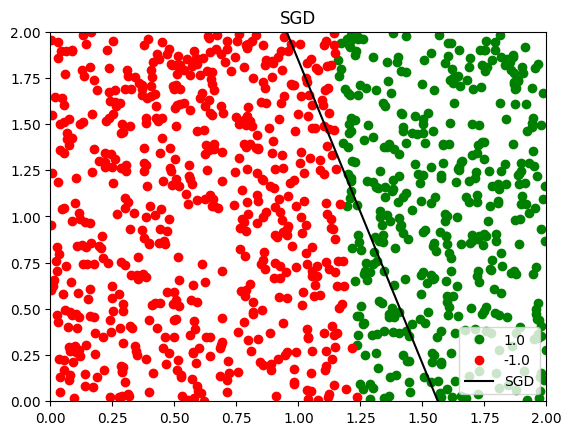

In [ ]:
mostrar_SGD(w,x_test,tags_test,intervalo,'SGD')


Al aplicar los pesos obtenidos a un problema de la misma naturaleza pero con cambios como puede ser el tamaño, se puede observar un resultado bueno pues tiene un porcentaje de acierto muy alto, aunque sin llegar a la perfección.

Este resultado es de esperar, ya que la muestra a testear tiene una diferencia de 900 puntos.

Con estos resultados y teniendo en cuenta que es normal obtener peores resultados en el test, el modelo se comporta como era esperado.


##### 4)


In [ ]:
list_epoc = []
list_eout = []
list_ein = []
list_accin = []
list_accout = []


In [ ]:
for i in np.arange(50):

  #Train

  x = simula_unif(100, 2, intervalo)
  a , b = simula_recta(intervalo)
  tags = etiquetado(x,a,b)

  X = transform_muestra(x)

  w, epocas = sgdRL(X, tags, 0.25, 2*10 , 10000)

  #Test

  x_test = simula_unif(1000, 2, intervalo)
  tags_test = etiquetado(x_test,a,b)

  X_test = transform_muestra(x_test)

  #Datos

  accin = Acc( tags, f_new(x[:,0], x[:,1], -w[1]/w[2], -w[0]/w[2])) * 100
  accout =  Acc( tags_test, f_new(x_test[:,0], x_test[:,1], -w[1]/w[2], -w[0]/w[2])) * 100
  ein = Err_(X,tags,w)
  eout = Err_(X_test,tags_test,w)
  
  #Listas

  list_epoc.append(epocas)
  list_eout.append(eout)
  list_ein.append(ein)
  list_accin.append(accin)
  list_accout.append(accout)


In [ ]:
epoc_media = np.mean(np.asarray(list_epoc))
eout_media = np.mean(np.asarray(list_eout))
ein_media = np.mean(np.asarray(list_ein))
accin_media = np.mean(np.asarray(list_accin))
accout_media = np.mean(np.asarray(list_accout))

print("Media de epocas: ", epoc_media)
print("Media de Eout: ", eout_media)
print("Media de Ein: ", ein_media)
print("Media de Accin: ", accin_media)
print("Media de Accout: ", accout_media)


Media de epocas:  245.32
Media de Eout:  0.052802251888697
Media de Ein:  0.046228382786981076
Media de Accin:  97.3
Media de Accout:  96.52999999999999


En esta cuarta parte del experimento se repitió lo anterior 50 veces, consiguiendo así una media de cada uno de los resultados. 

Los resultados son buenos, consiguiendo un error medio muy pequeño de entrada y de salida. En teoría el Eout y el ACCout debería ser peor pues los pesos están siendo aplicados y no entrenados, pero a mi manera de ver la naturaleza del problema es muy similar, por lo que me parece razonable que se obtengan resultados muy parecidos. Destacando aún así que se cumple con lo nombrado anteriormente. 


##### Conclusiones


En respuesta a las cuestiones que se nos plantean si cambiasemos la condición de parada a la iteraciones el algoritmo sería más inestable y tendría mucha más carga computacional. 

El learning rate y el minibatch elegido es muy importante para este algoritmo, de esto dependerá si saldrá un buen resultado o no.

Se ha tenido en cuenta que si el lr es demasiado grande, puede diverger y no llegar a un mínimo local, en cambio si es muy pequeño, el algoritmo irá más lento, necesitando muchas más iteraciones para una solución aceptable

Para el minibatch se ha tenido en cuenta el coste computacional que puede llegar a tener darle un valor muy alto. Además, si su valor es muy pequeño, la convergencia será muy lenta.

Finalmente se llegó a la elección teniendo en cuenta los factores anteriores y un tiempo de experimentación empírica en busca del ideal.


##### <font color='blue'>Ahora repita el mismo experimento, pero empleando datos no linealmente separables. Para ello, debe introducirse un 10% de ruido por clase. 


##### 1)


Este punto es exactamente igual al anterior, con la diferencia de que se añade ruido a la muestra, un 10% en este caso.


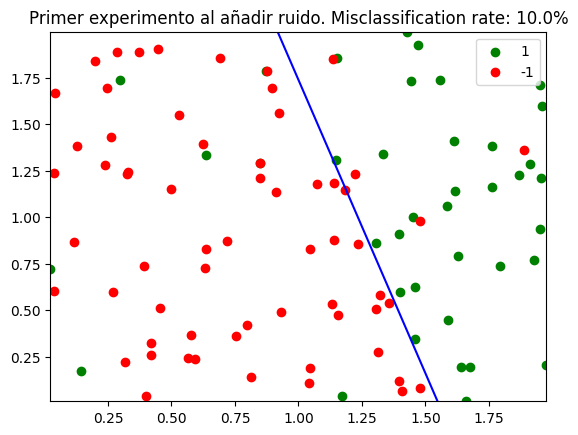

In [ ]:
np.random.seed(0)

intervalo=[0,2]

# Recta y points etiquetados
a, b = simula_recta(intervalo)

# Muestras
x = simula_unif(100, 2, intervalo) 

tags = etiquetado(x,a,b)
tags_noise = noise(tags,0.1,0.1)

err2 = ErrorClasificacion(x, tags_noise, a, b)
title1_a = "Primer experimento al añadir ruido. Misclassification rate: " + str(err2) + "%"

# Gráfica
mostrar_clasif(x, tags_noise, a, b, title1_a, "1", "-1")


##### 2)


In [ ]:
X = transform_muestra(x)

w, epocas = sgdRL(X, tags_noise, 0.2, 2*10 , 10000)


In [ ]:
print("El algoritmo ha iterado durante",str(epocas),"épocas")
print("W: ",w)
print("Acc: ",Acc(tags_noise,f_new(x[:,0], x[:,1], -w[1]/w[2], -w[0]/w[2])) * 100,"%")
print("Ein de la muestra: ", Err_(X,tags_noise,w))


El algoritmo ha iterado durante 10000 épocas
W:  [-5.31843528  3.1258739   0.62181938]
Acc:  81.0 %
Ein de la muestra:  0.4809294683254815


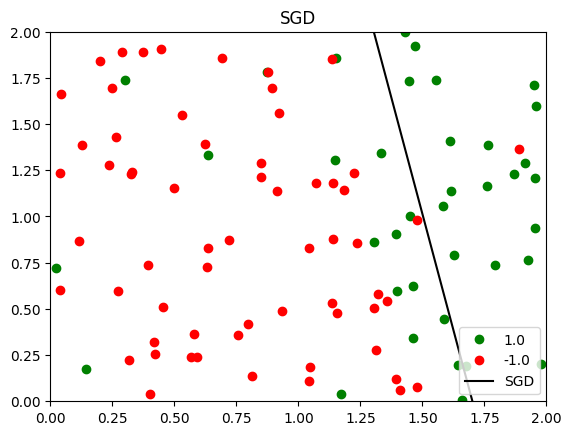

In [ ]:
mostrar_SGD(w,x,tags_noise,intervalo,'SGD')


Tras la ejecución del algoritmo conseguimos resultados que nos indican varias cosas. Aunque el algoritmo obtuvo un buen resultado en lo que respecta al Accuracy, el Ein es muy alto, indicando que el algoritmo no puede adaptarse bien a la muestra puesto que los datos no son linealmente separables.


##### 3)


In [ ]:
np.random.seed(1)

intervalo=[0,2]
x_test = simula_unif(1000, 2, intervalo)
a , b = simula_recta(intervalo)
tags_test = etiquetado(x_test,a,b)
tags_test_n = noise(tags_test,0.1,0.1)

X_test = transform_muestra(x_test)


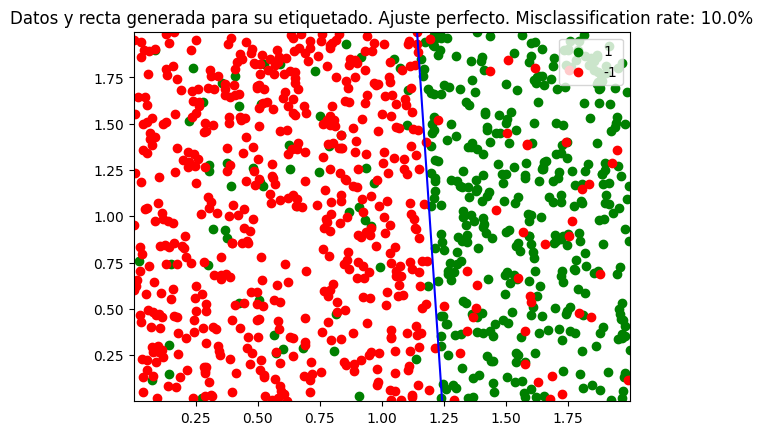

In [ ]:
err21 = ErrorClasificacion(x_test, tags_test_n, a, b)
title1_a = "Datos y recta generada para su etiquetado. Ajuste perfecto. Misclassification rate: " + str(err21) + "%"

# Gráfica
mostrar_clasif(x_test, tags_test_n, a, b, title1_a, "1", "-1")


In [ ]:
print("Estimación del error Eout: ", Err_(X_test,tags_test_n,w))
print("Acc: ",Acc(tags_test_n,f_new(x_test[:,0], x_test[:,1], -w[1]/w[2], -w[0]/w[2])) * 100,"%")


Estimación del error Eout:  0.49016832757438455
Acc:  77.0 %


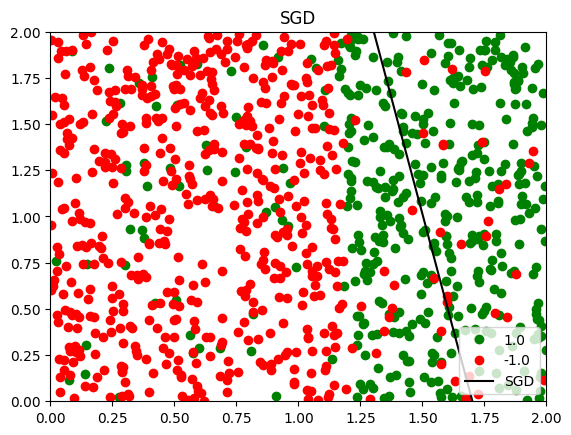

In [ ]:
mostrar_SGD(w,x_test,tags_test_n,intervalo,'SGD')


Tras este apartado del experimento se pueden hacer varias anotaciones. La naturaleza del problema es muy parecida y por tanto el Accuracy aun en muestras aleatorias es posible incluso que sea mejor en el test, ya que existen muchos más points y existe la posibilidad de que se clasifiquen correctamente, aunque ese no sea este caso. En este caso con una muestra 10 veces mayor la clasificación conseguida al aplicar los pesos a ésta ha sido peor.

En este caso el Eout obtenido es muy parecido al Ein, indicando que el modelo se comporta de una forma similar, pero el Accuracy ha bajado pues el porcentaje de aciertos conseguidos es menor.


##### 4)


In [ ]:
list_epocn = []
list_eoutn = []
list_einn = []
list_accinn = []
list_accoutn = []


In [ ]:
for i in np.arange(50):

  #Train

  x = simula_unif(100, 2, intervalo)
  a , b = simula_recta(intervalo)
  tags = etiquetado(x,a,b)
  tags_n = noise(tags,0.1,0.1)

  X = transform_muestra(x)

  w, epocas = sgdRL(X, tags_n, 0.05, 2*10 , 10000)

  #Test

  x_test = simula_unif(1000, 2, intervalo)
  tags_test = etiquetado(x_test,a,b)
  tags_test_n = noise(tags_test,0.1,0.1)


  X_test = transform_muestra(x_test)

  #Datos

  accin = Acc( tags_n, f_new(x[:,0], x[:,1], -w[1]/w[2], -w[0]/w[2])) * 100
  accout =  Acc( tags_test_n, f_new(x_test[:,0], x_test[:,1], -w[1]/w[2], -w[0]/w[2])) * 100
  ein = Err_(X,tags_n,w)
  eout = Err_(X_test,tags_test_n,w)
  
  #Listas

  list_epocn.append(epocas)
  list_eoutn.append(eout)
  list_einn.append(ein)
  list_accinn.append(accin)
  list_accoutn.append(accout)


In [ ]:
epoc_median = np.mean(np.asarray(list_epocn))
eout_median = np.mean(np.asarray(list_eoutn))
ein_median = np.mean(np.asarray(list_einn))
accin_median = np.mean(np.asarray(list_accinn))
accout_median = np.mean(np.asarray(list_accoutn))

print("Media de epocas: ", epoc_median)
print("Media de Eout: ", eout_median)
print("Media de Ein: ", ein_median)
print("Media de Accin: ", accin_median)
print("Media de Accout: ", accout_median)


Media de epocas:  576.54
Media de Eout:  0.4229109889939746
Media de Ein:  0.41665327235256133
Media de Accin:  85.52
Media de Accout:  85.426


Con este apartado se finaliza el experimento. Antes que nada es necesario contar algunos cambios, puesto que se tuvo que modificar el lr ya que era demasiado tiempo de esperar a la convergencia en este caso. Se hizo más pequeño lr para que aunque teoricamente se necesiten más iteraciones, sea un camino más seguro y llegue pues si es muy grande el lr oscilará buscando la solución y tardará incluso más todavñia.

Al introducir ruido el porcentaje de acierto decae pues ya no es linealmente separable, obteniendo peores resultados que al no usar ruido, se puede notar en por ejemplo el Ein y Eout usando ruido y sin usar, teniendo una gran distancia de valores entre un Ein sin ruido con un Ein con ruido, lo mismo con Eout.

Por lo que siguiendo esta premisa, el Ein y Eout con ruido tienen un mayor valor que el Ein y Eout sin ruido. Mientras, el accuracy en las muestras con ruido tienen un valor menor que un accuracy con muestras sin ruido.
